In [1]:
import numpy as np
from matplotlib import pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader


## Note on reproducibility:
NN-training has many forms of stochasticity, sometimes quite hidden. Usually, you want to create reproducible code. Setting the seed is mostly enough, but not always. 

Have a look at the official guide for detailed information:
https://docs.pytorch.org/docs/stable/notes/randomness.html

I will give you a short tutorial explaining the background about random number generators, and how to use them in your Python notebooks for reproducibility.

### Random Number Generators
Random number generators (RNGs) produce a deterministic sequence of numbers that looks random.
The sequence depends on a seed. If you set the same seed, you will always get the same sequence of random numbers.


### Example 1: setting the seed and getting the first 10 random numbers:

In [2]:
torch.manual_seed(0)      # set the seed, resets the random number generator
print(torch.rand(10))     # print the first 10 numbers of the sequence of "random" numbers with this seed


tensor([0.4963, 0.7682, 0.0885, 0.1320, 0.3074, 0.6341, 0.4901, 0.8964, 0.4556,
        0.6323])


Re-running the above cell always gives the same output.
Setting the seed reinitializes the random number generator.

### Example 2: executing a cell without setting the seed _in this cell_
If we set the seed once, e.g. the start of our project, and then execute cells multiple times without setting the seed, it will give different results.

In [3]:
torch.manual_seed(0)    # resets the random number generator

In [4]:
# Execute this cell multiple times. The output seems "random" at each execution. Note how it produces the same sequence as in Example 1. 
print(torch.rand(1)) 
# If you execute the cell above (setting the seed) in between, the sequence will start from the beginning again.

tensor([0.4963])


### Why Set the Seed?

Any operation involving randomness (dataset splitting, weight initialization, data augmentation, etc.) will give different results every time you execute the cell unless you set a seed. This makes it more difficult for you to report your findings. 

Since there are multiple different random generators used in the background (one for basic Python, one from PyTorch, and one from CUDA), you can use the function below to set all the seeds at once.

Note: even with all seeds set, PyTorch may not be fully reproducible on different machines due to hardware-dependent operations.

In [5]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)    # use this function call at the beginning of every cell!
torch.randn(1)  # example to show it works.

tensor([0.3367])

# Data Augmentation only on the Training set
In Assignment 2, you want to compare the validation performance with and without data augmentation. For a fair comparison, the validation set needs to be the same (without augmentation). If you would first augment the dataset and split it, this would be violated. 

Below, I will show you two options how to achieve this in PyTorch.

### Option 1: Create two copies of the dataset
This is the "quick and dirty" option, which is sufficient for the small datasets we are using. 
We create a second copy of the dataset, one with transforms and one without, and use the one with transformations for training. 


In [6]:
# Helper methods to track memory consumption and compare the options
import os, psutil
process = psutil.Process(os.getpid())
def mem_mb():
    return process.memory_info().rss / 1024**2


In [7]:
import numpy as np
from matplotlib import pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split


# Set random seed for reproducibility
torch.manual_seed(302)
np.random.seed(302)

train_transform = transforms.Compose([
    transforms.RandomRotation(90),  # Extreme example so easily see the difference in visualization
    transforms.ToTensor(),
    transforms.Normalize((0.5), (0.5))
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5), (0.5))
])

print("Before datasets:", mem_mb(), "MB")
train_full = datasets.MNIST(root='./data', train=True, download=True, transform=train_transform)
print("After train_full:", mem_mb(), "MB")
val_full   = datasets.MNIST(root='./data', train=True, download=False, transform=val_transform)
print("After val_full:  ", mem_mb(), "MB")

train_size = int(0.8 * len(train_full))
val_size = len(train_full) - train_size

train_indices, val_indices = random_split(range(len(train_full)), [train_size, val_size])     # split on the indices, not the dataset itself

trainset = torch.utils.data.Subset(train_full, train_indices)                        # use the indices to split the full train dataset
valset   = torch.utils.data.Subset(val_full,   val_indices)                          # use the indices to split the full val dataset

train_loader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
val_loader = torch.utils.data.DataLoader(valset, batch_size=64, shuffle=True)


Before datasets: 524.94921875 MB
After train_full: 570.1171875 MB
After val_full:   615.01953125 MB
After val_full:   615.01953125 MB


In [8]:
def plot_image_grid(dataloader):
    # Get a batch of images and labels
    images, labels = next(iter(dataloader))
    plt.figure(figsize=(13, 8))
    for i in range(min(32, len(images))):
        plt.subplot(4, 8, i+1)
        plt.imshow(images[i].squeeze().numpy(), cmap='gray')
        plt.title(labels[i].item())
        plt.axis('off')
    plt.tight_layout()
    plt.show()

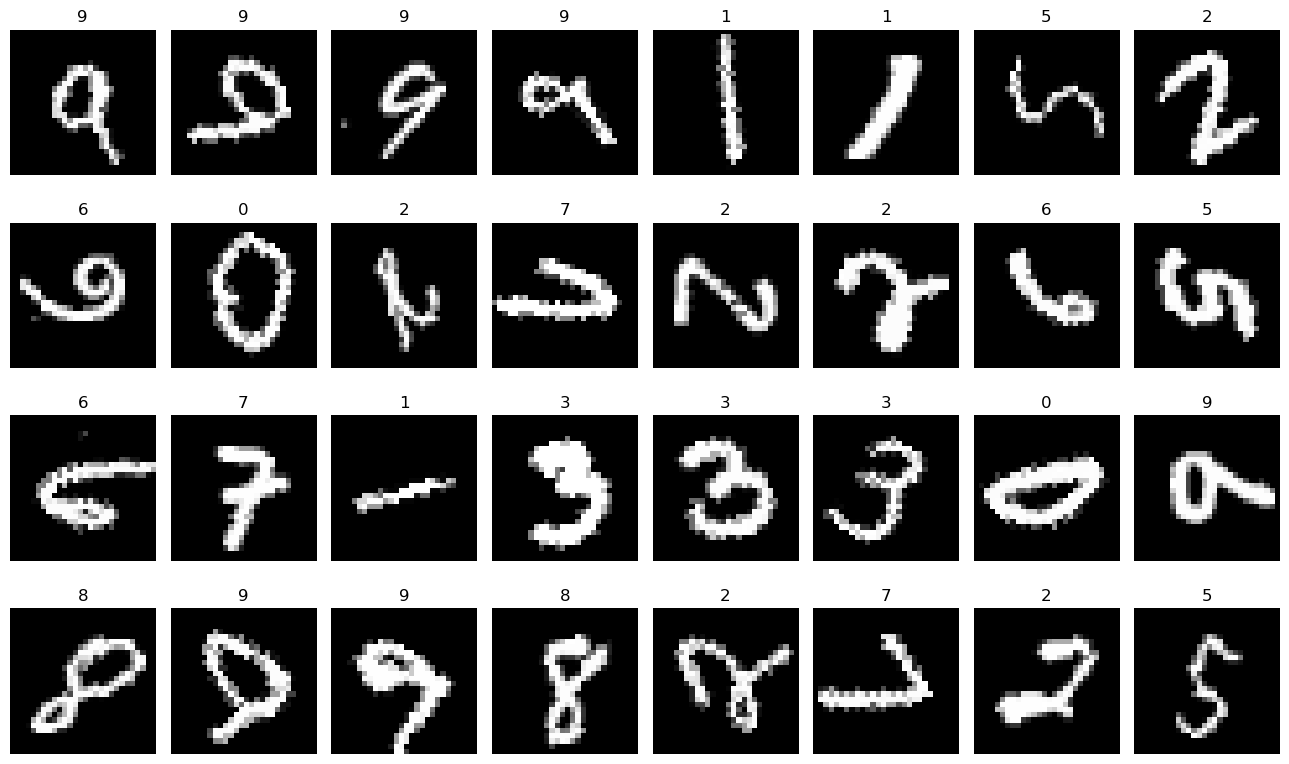

In [9]:
plot_image_grid(train_loader) # samples with rotation

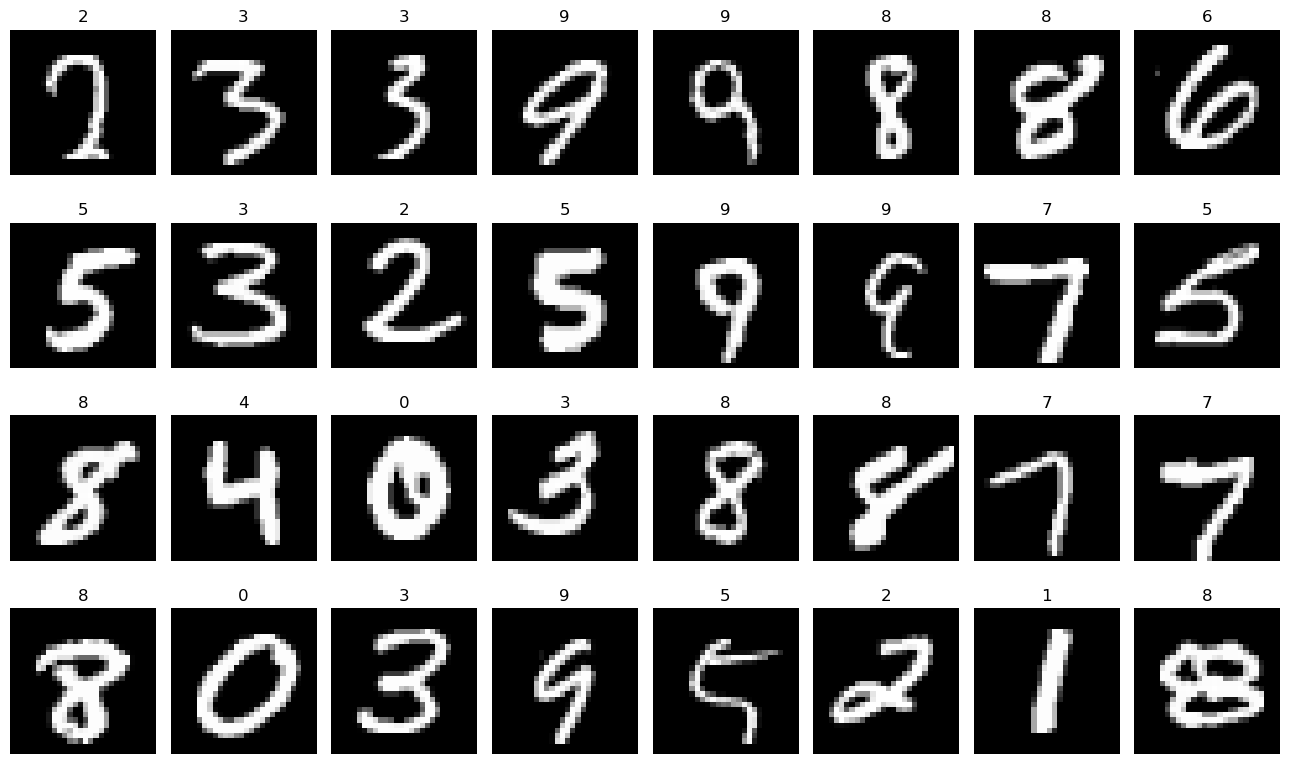

In [10]:
plot_image_grid(val_loader) # samples without rotation

### Option 2: Slightly more code, but cleaner and more efficient
The cleaner and more PyTorch-aligned option is to create our own Dataset, where we can include the transformations we want. 

In many cases, where you use your own dataset which you cannot just load from _torchvision_, you would need to create your own dataset wrapper anyway, so this is a very natural approach.

We need to create a class that inherits from _Dataset_ and implement the required methods.

In [11]:
from torch.utils.data import Dataset, random_split, DataLoader
from torchvision import datasets, transforms
import os, psutil, torch



train_transform = transforms.Compose([
    transforms.RandomRotation(90),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

print("Before datasets:", mem_mb(), "MB")

base = datasets.MNIST(root='./data', train=True, download=True, transform=None)


train_size = int(0.8 * len(base))
val_size   = len(base) - train_size

train_indices, val_indices = random_split(range(len(base)), [train_size, val_size])

class TransformSubset(Dataset):
    def __init__(self, dataset, indices, transform=None):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img, label = self.dataset[self.indices[idx]]
        if self.transform is not None:
            img = self.transform(img)
        return img, label
    


trainset = TransformSubset(base, train_indices, transform=train_transform)
print("After train_full:", mem_mb(), "MB")
valset   = TransformSubset(base, val_indices, transform=val_transform)
print("After val_full:  ", mem_mb(), "MB")  # should be almost equal -> no duplication, of the dataset, just accessing with different transformations

train_loader = DataLoader(trainset, batch_size=64, shuffle=True)
val_loader   = DataLoader(valset,   batch_size=64, shuffle=False)

Before datasets: 653.109375 MB
After train_full: 698.07421875 MB
After val_full:   698.07421875 MB


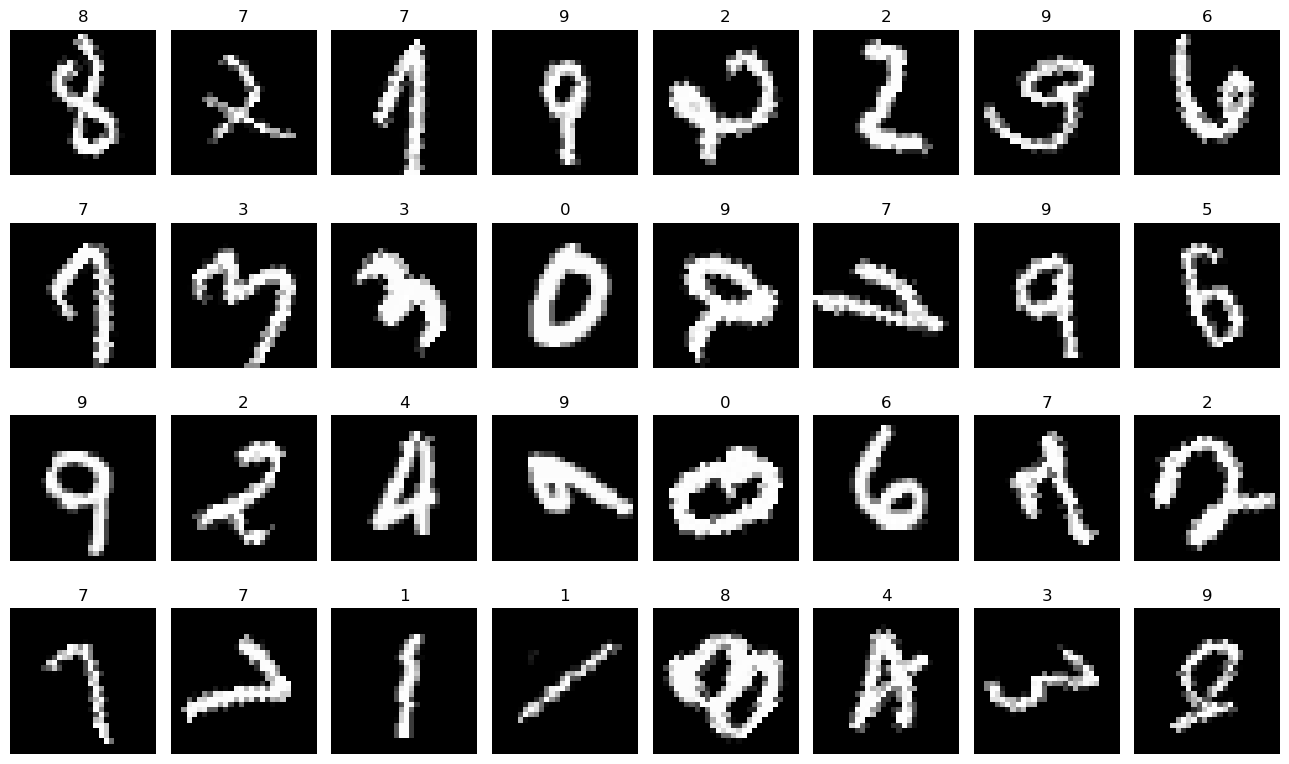

In [12]:
plot_image_grid(train_loader) # samples with rotation

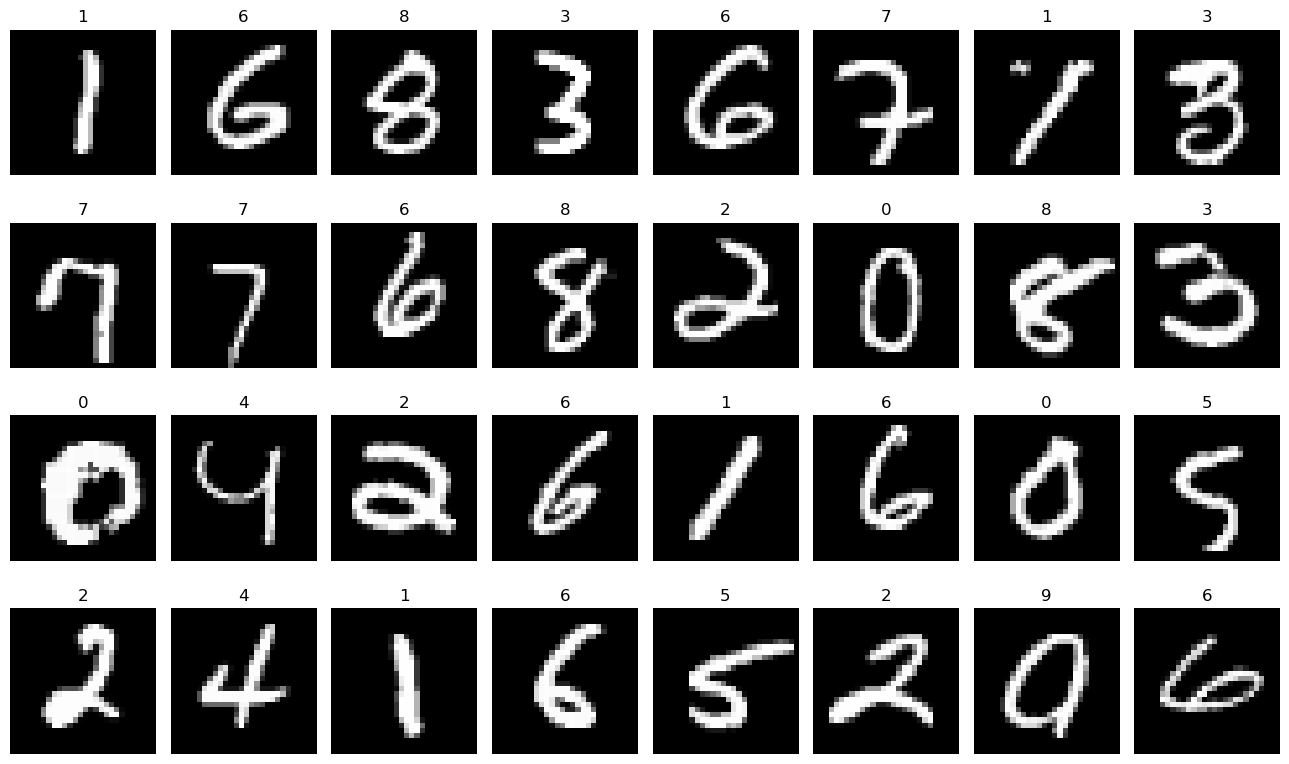

In [13]:
plot_image_grid(val_loader) # samples with rotation

## Speeding up training
As some of you have noticed, moving the training to GPU does not improve the training speed significantly. This is because we are using rather small models, and small datasets (28x28 pixels). Modern GPUs can handle these easily, and the bottleneck is actually the dataloading or the shifting of data from CPU to GPU memory. 

One way to speed those things up is by setting some parameters in the dataloader. 
- _num\_workers_ controls the number of subprocesses used for dataloading. Setting this to 4 or 8 allows PyTorch to utilize more CPU power for dataloading.
- _pin\_memory = True_ can also speed up processing. More information on this can be found here: https://pytorch.org/tutorials/intermediate/pinmem_nonblock.html

Increasing batch size can also help utilize GPU more efficiently, but of course this will also impact training. There are many other ways you can improve training performance, but they are not the focus of this course. If you are interested, however, a good starting point is this tutorial: https://pytorch.org/tutorials/recipes/recipes/tuning_guide.html

# Confusion Matrix
Task c) asks about the confusion matrix. Here is a short explanation of what it is and how to plot one in Python. You may reuse this code in your assignment, but make sure you use it correclty (correct parameters, etc.)! You can also use this function: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html

### What Is a Confusion Matrix?

A confusion matrix is a table that summarizes how well a classification model performs.
For a dataset like CIFAR-10 (10 classes), the confusion matrix is a 10×10 grid where:

- Rows = Actual labels (ground truth)
- Columns = Predicted labels (model output)

Each cell tells you how many samples of an actual class were predicted as another class.

More information can be found here: https://www.geeksforgeeks.org/machine-learning/confusion-matrix-machine-learning/


Confusion matrix (rows = true class, columns = predicted class):
tensor([[119, 131, 114, 140, 125,  99, 110, 125, 111, 114],
        [134, 136, 144, 127, 122, 148, 146, 136, 141, 110],
        [114, 122, 132, 107, 112, 110, 111, 106, 125, 134],
        [108, 118, 120, 123, 125, 111, 119, 134, 117, 118],
        [105, 103, 107, 115, 100, 134, 113, 109, 113, 123],
        [ 99, 105, 121, 111, 101,  95, 121, 118, 107,  99],
        [122, 110, 113, 114, 126, 118, 121, 126, 130, 124],
        [133, 142, 117, 122, 135, 138, 124, 150, 130, 124],
        [130, 106, 116, 135, 119, 120, 113, 126, 122, 114],
        [114, 119, 106, 113, 116, 123, 113, 124, 126, 129]])


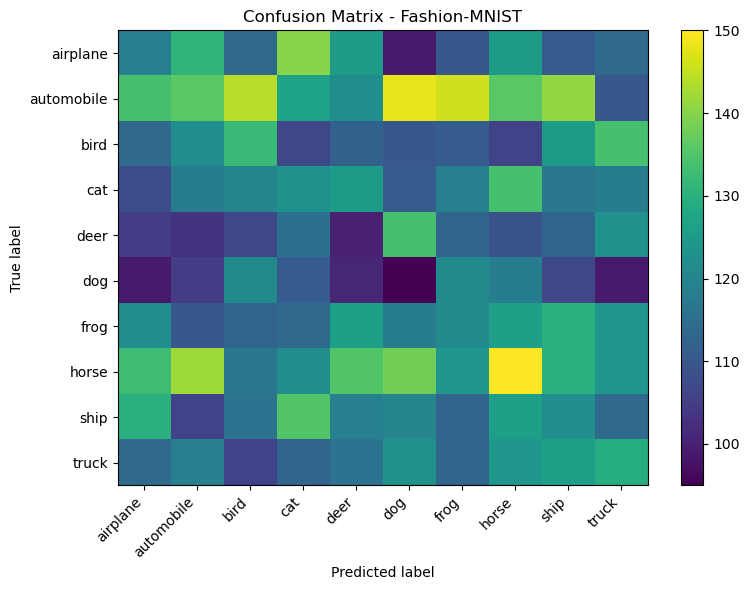

In [21]:
# Confusion matrix
def compute_confusion_matrix(model, data_loader, num_classes, device):
    model.eval()
    cm = torch.zeros(num_classes, num_classes, dtype=torch.int64)
    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            for t, p in zip(targets.view(-1), preds.view(-1)):
                cm[t.long(), p.long()] += 1
    return cm


# Use your model instead
class MockModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.num_classes = num_classes

    def forward(self, x):
        # x: (batch_size, C, H, W) or similar
        batch_size = x.size(0)
        # random logits on the same device as x
        return torch.randn(batch_size, self.num_classes, device=x.device)

set_seed(42)
num_classes = 10
device = torch.device("cpu")
final_model = MockModel(num_classes).to(device)
test_dataset = datasets.CIFAR10('./data', train=False)  # you already did this somewhere else most likely


cm = compute_confusion_matrix(final_model, val_loader, num_classes, device) # make sure you use the correct dataloader here!
print("\nConfusion matrix (rows = true class, columns = predicted class):")
print(cm)


# Plot confusion matrix as heatmap
class_names = test_dataset.classes  # list of class labels
plt.figure(figsize=(8, 6))
plt.imshow(cm.numpy(), interpolation='nearest', aspect='auto')
plt.title("Confusion Matrix - Fashion-MNIST")
plt.colorbar()
tick_marks = np.arange(num_classes)
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

The above example shows a confusion matrix based on random predictions (since I didn't train a model in this tutorial), so the result is just noise. When you plot the confusion matrix for your trained model, it should look very different (ideally with high values on the diagonal)!